In [2]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.txt"
path = ("/content/drive/MyDrive/household_power_consumption.txt")
df = pd.read_csv(
    path,
    sep=';',
    low_memory=False
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
df = df.sample(50000, random_state=42)

In [4]:
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')

In [5]:
df = df.dropna(subset=['datetime'])

In [6]:
numeric_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
df = df.dropna(subset=numeric_cols)

In [8]:
df.set_index('datetime', inplace=True)

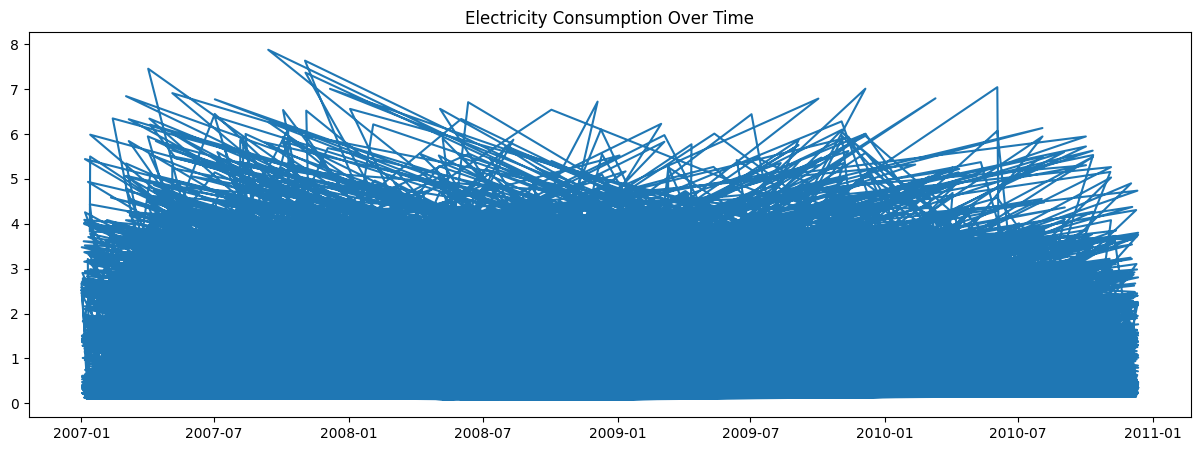

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df.index, df['Global_active_power'])
plt.title("Electricity Consumption Over Time")
plt.show()

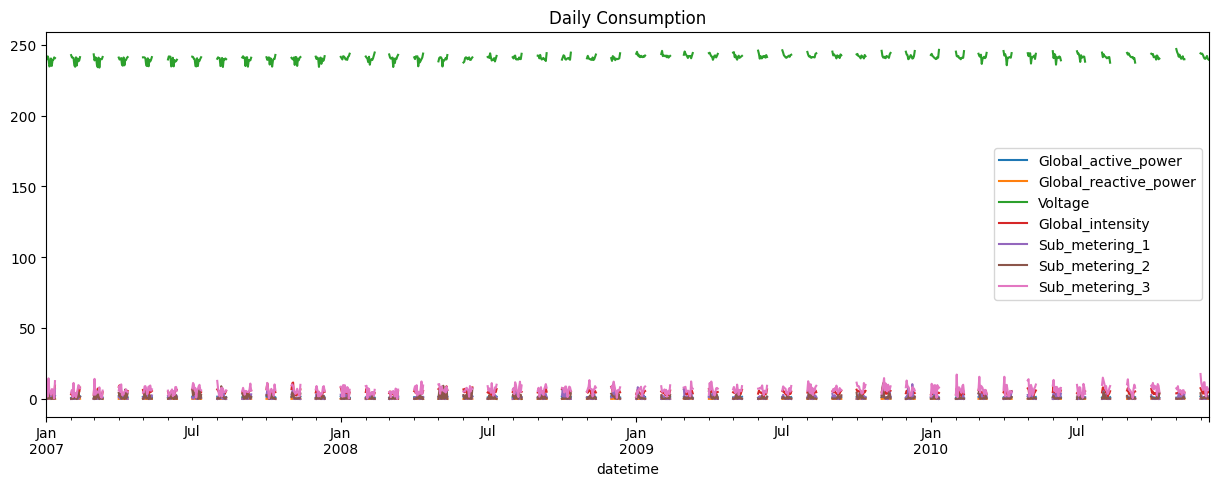

In [10]:
# Ensure the columns in df are numeric and handle NaNs before creating df_numeric
# This is a defensive step, assuming the prior cells might not have fully updated `df`'s dtypes as expected.
# Using the `numeric_cols` variable from the notebook state.
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=numeric_cols)

# Select only the explicitly numeric columns for resampling
df_numeric = df[numeric_cols]

# Now resample and plot
daily = df_numeric.resample('D').mean()

daily.plot(figsize=(15,5), title="Daily Consumption")
plt.show()

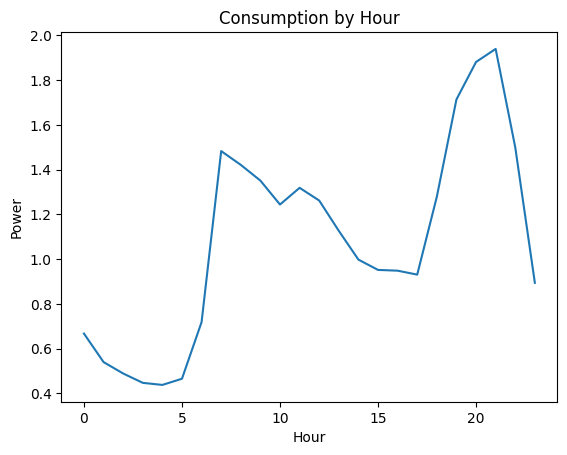

In [11]:
df['hour'] = df.index.hour

hourly_avg = df.groupby('hour')['Global_active_power'].mean()

plt.plot(hourly_avg.index, hourly_avg.values)
plt.title("Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Power")
plt.show()

In [12]:
df['day'] = df.index.day
df['month'] = df.index.month

X = df[['hour', 'day', 'month']]
y = df['Global_active_power']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [15]:
predictions = model.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)

MAE: 0.7513608936962569


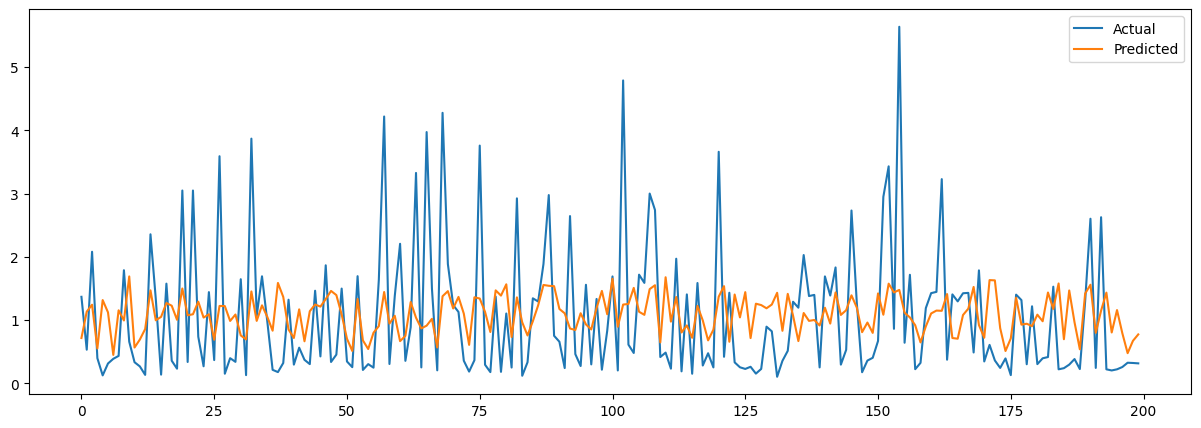

In [17]:
plt.figure(figsize=(15,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(predictions[:200], label="Predicted")
plt.legend()
plt.show()

In [18]:
df.to_csv("cleaned_energy.csv")

In [19]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 116.0 MB/s eta 0:00:00


In [20]:
%%writefile app.py
import streamlit as st

st.title("⚡ Energy Dashboard")
st.write("Hello from Streamlit 👋")

Writing app.py


In [1]:
!streamlit run app.py &

/bin/bash: line 1: streamlit: command not found


In [22]:
!pip install streamlit

In [24]:
!pip install pyngrok